# Top level imports

In [1]:
# Imports
import os
from pathlib import Path
from urllib.parse import urlparse

from fastai.vision.all import *
from fastai.vision.core import *

from PIL import ImageFilter, Image
import numpy as np

import ipyplot

from ipynb.fs.full.Deink_00_Utils import *
from ipynb.fs.full.Deink_00_Utils import _get_sil_y 

Image Size: (640, 480)


# Set up top level variables

In [2]:
# Where we should save our in-process model
callback_saved_model = Path("./callback_saved_model")
every_epoch=10
print(f"Temp model saving in {callback_saved_model.parent.resolve()} / {os.path.basename(callback_saved_model)}")

# Control for the number of epocs to run
epocs = 300
#epocs = 10
start_epoch=0
print(f"Traing {epocs} epocs, starting on {start_epoch}")

Temp model saving in /home/jovyan/work/kozobot/deinked / callback_saved_model


# Pre-Trained Generator

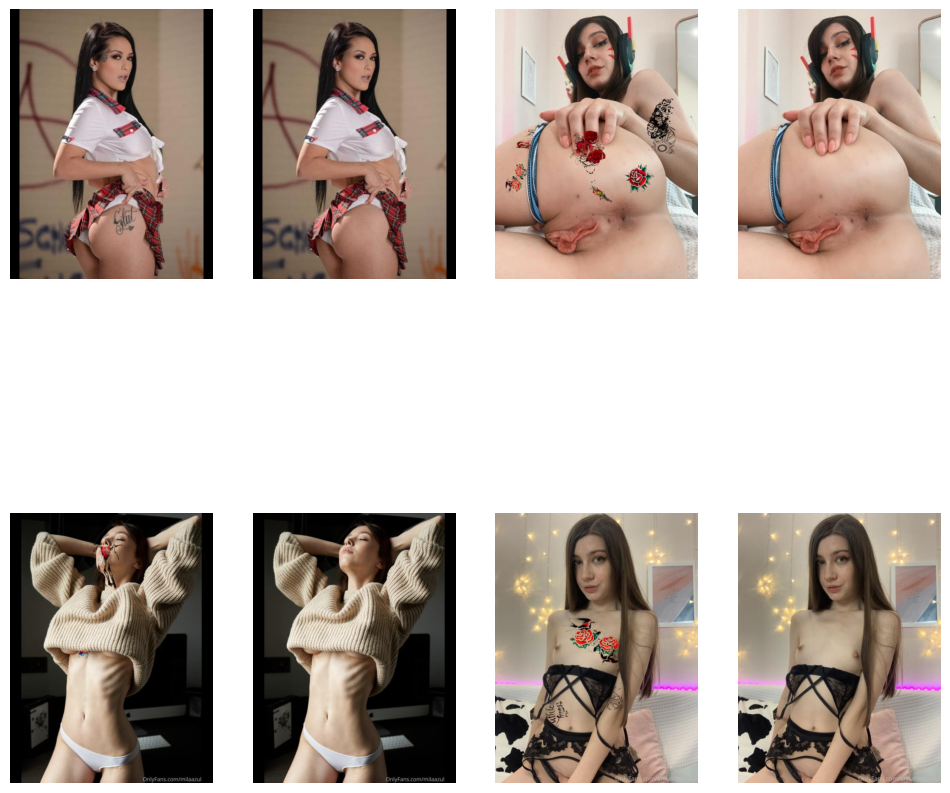

In [3]:
# Load our training data
dls_gen = get_dls(batch_size, image_size) 
dls_gen.show_batch(max_n=4, figsize=(12,12))

In [4]:
# For our backbone
#bbone = resnet34  
bbone = xresnet34_deeper # clear images slightly faded tatts about 7 sec per run
#bbone = resnet50 
#bbone = resnet18 
#bbone = squeezenet1_0 # blue pixelated; about 4 sec per run
#bbone = densenet121 # ran out of mem
#bbone = vgg16_bn # purple pixelated; about 5 sec per run
#bbone = vgg19_bn # blurry images with faded tatts; about 5 sec per run
#bbone = alexnet # pink blocks then blank; about 4 sec per run
def create_gen_learner():
    basename = os.path.basename(callback_saved_model)
    fname = callback_saved_model.parent.resolve()
    
    #cnn_learner??
    learner = unet_learner(dls_gen, bbone, 
                           path=fname,
                           loss_func=loss_gen,
                           blur=True, 
                           norm_type=NormType.Weight,
                           self_attention=True,
                           y_range=y_range,
                           cbs=[
                               # Set things up so that we can resume a crashed training session
                               SaveModelCallback(with_opt=True, fname=basename, every_epoch=every_epoch)
                           ]) 
    
    # See if we need to restore the existing model    
    model_path = Path(f'{fname}/models/{basename}_{start_epoch}.pth')
    if model_path.exists() and start_epoch > 0:
        print(f"WARNING: Resuming existing model training from {model_path} at epoch {start_epoch}")
        learner.load(f'{basename}_{start_epoch}')
        
    return learner

In [5]:
# Let's create our learner
learn_gen = create_gen_learner()

# Do the Learning

# What callbacks do we want
cbs = []
csv_append = True
if (start_epoch == 0):
    cbs.append(ShowGraphCallback())
    csv_append = False # overwrite whatever is there since we are starting at the beginning
    
# Add a logger to write to csv
cbs.append(CSVLogger(fname=f'deink-{bbone.__name__}-epocs{epocs}_history.csv', append=csv_append))

# Do the learning
learn_gen.fit_one_cycle(epocs,
                        pct_start=0.3,
                        wd=wd,
                        start_epoch=start_epoch,
                        cbs=cbs
                       )

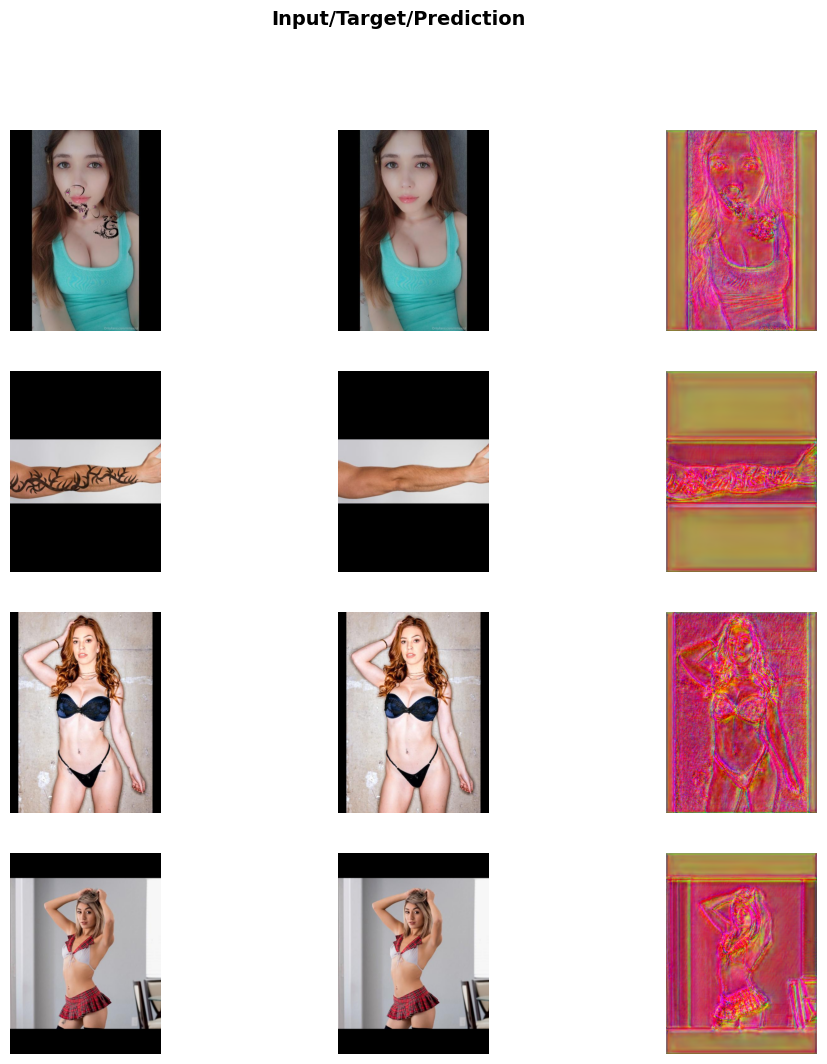

In [6]:
learn_gen.show_results(max_n=4, figsize=(12,12))

# Export the Model

In [7]:
#save the model
deinked_gen_model_file = f'./deinked-{bbone.__name__}-epocs{epocs}.pkl'
learn_gen.export(deinked_gen_model_file)
print(f'Storing model {deinked_gen_model_file}')

%store deinked_gen_model_file

./deinked-xresnet34_deeper-epocs300.pkl


# Quick test run

In [8]:
# Load a test file
img_fast_raw = PILImage.create("./data/deinked/test/0010-15.jpg")

resize = Resize(image_size, 
                 resamples=(Image.BILINEAR, Image.NEAREST),
                 method=ResizeMethod.Pad,
                 pad_mode=PadMode.Zeros)

img_fast = resize(img_fast_raw, split_idx=1).convert("RGB")
display(img_fast)

In [9]:
# Run our prediction
tensor_image, img_hr_tensor_base, preds_tensor_base = learn_gen.predict(img_fast)

Error: no "view" rule for type "image/png" passed its test case
       (for more information, add "--debug=1" on the command line)
/usr/bin/xdg-open: 869: www-browser: not found
/usr/bin/xdg-open: 869: links2: not found
/usr/bin/xdg-open: 869: elinks: not found
/usr/bin/xdg-open: 869: links: not found
/usr/bin/xdg-open: 869: lynx: not found
/usr/bin/xdg-open: 869: w3m: not found
xdg-open: no method available for opening '/tmp/tmp83x7we8q.PNG'


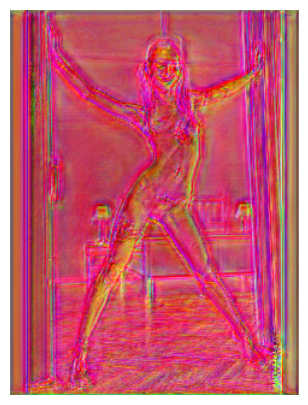

In [10]:
# Show our results
pil_image = PILImage.create(tensor_image)
pil_image.show()
pil_image.save(f"deink-{bbone.__name__}-epocs{epocs}_0010-15.jpg")